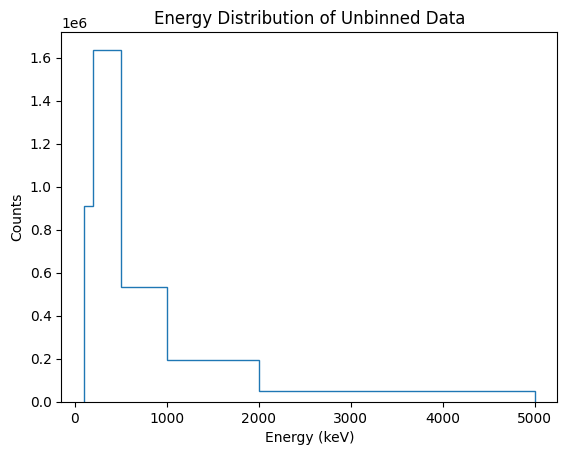

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# code is from StackOverflow https://stackoverflow.com/questions/46733052/read-hdf5-file-into-numpy-array
hf = h5py.File("unbinned_data.hdf5", "r")
dict_to_arr = hf.get('Energies')             # found key from cosipy read the docs under the function read_tra
energy_values = np.array(dict_to_arr)


#plt.hist returns a np.array of ([values], [edges])
Energy_count, Energy_bins, patches= plt.hist(energy_values, bins=[100.,  200.,  500., 1000., 2000., 5000.], histtype='step')

# axis is count vs energy
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Energy Distribution of Unbinned Data")
plt.show()

# cant use this one because it is not evenly spaced
# try y-axis / x-axis to get the rate for light curve

# went with this one becasue more of a general approach
# or try y-axis / x1-x2 to get the range of bins for light curve

In [23]:
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[ 100.  300.  500. 1000. 3000.]


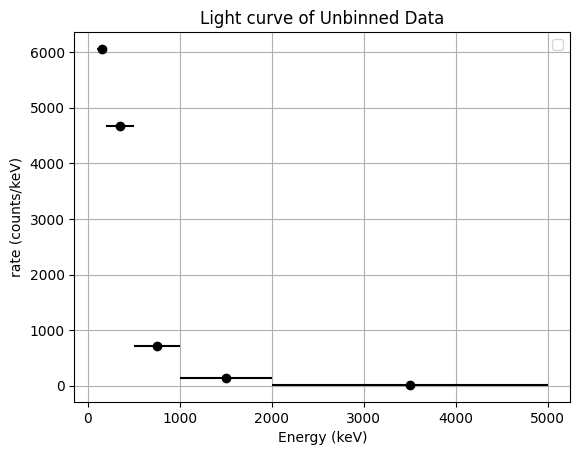

In [60]:
import matplotlib.pyplot as plt

hf = h5py.File("unbinned_data.hdf5", "r")

# spectra graph is rate (count/keV^-1) vs energy (kev)
# x axis are the energy means???? idk man
# y axis is the rate (y/x from the histogram)
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2
rate = Energy_count / bins_widths_center  # rate is counts per bin width

#formating it all together

# plt.plot(bins_widths_center, rate, marker='o', color = 'black', linestyle='None', label = 'raw spectrum')

# why????? is it / 2, maybe becasue im plotting them in the center
x_errors = (Energy_bins[1:] - Energy_bins[0:-1]) / 2  # calculate the bin widths for error bars

print((Energy_bins[1:] - Energy_bins[0:-1]))

plt.errorbar(bins_widths_center, rate, xerr=x_errors, fmt='o', color='black')


plt.xlabel("Energy (keV)")
plt.ylabel("rate (counts/keV)")
plt.title("Light curve of Unbinned Data")
plt.legend()
plt.grid(True)
plt.show()

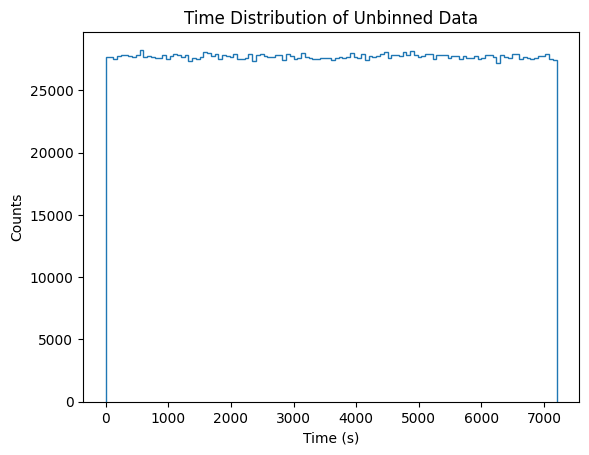

In [59]:
time_arr = hf.get('TimeTags')  # found key from cosipy read the docs under the function read_tra
time_values = np.array(time_arr)    

relative_time = time_values - time_values[0]  

bin_width_const = 60  # seconds, this is the bin width for the light curve

# param for np.arange (start, stop, step)
bin_width = np.arange(0, relative_time[-1] + bin_width_const, bin_width_const)


count_times, time_bins, _ = plt.hist(relative_time, bins=bin_width, histtype='step')
plt.xlabel("Time (s)")
plt.ylabel("Counts")
plt.title("Time Distribution of Unbinned Data")
plt.show()

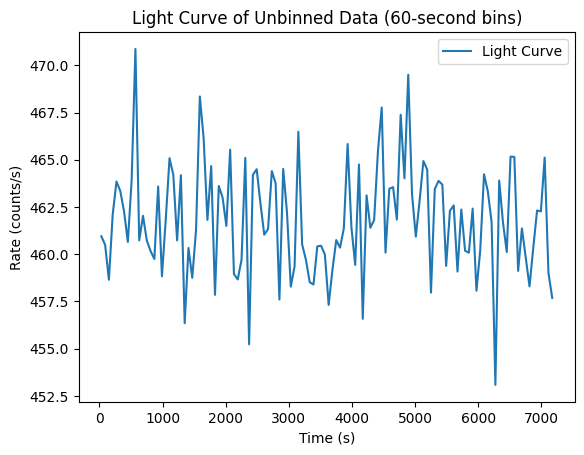

In [65]:
# Calculate rate = count / bin_width using the results from plt.hist

# x-axis is time bin centers (average of bin edges)
time_bin_center = (time_bins[1:] + time_bins[:-1]) / 2

time_bin_widths = time_bins[1:] - time_bins[:-1]  

# Note: rate is y-axis / x1-x2
rate_times = count_times / time_bin_widths    

# Create the light curve plot
plt.plot(time_bin_center, rate_times, linestyle='-', label='Light Curve')
plt.xlabel("Time (s)")
plt.ylabel("Rate (counts/s)")
plt.title("Light Curve of Unbinned Data (60-second bins)")
plt.legend()
plt.show()

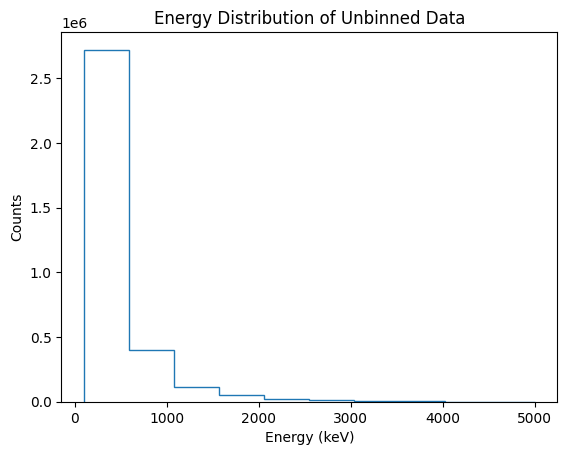

[244.99655 244.99655 244.99655 244.99655 244.99655 244.99655 244.99655
 244.99655 244.99655 244.99655]


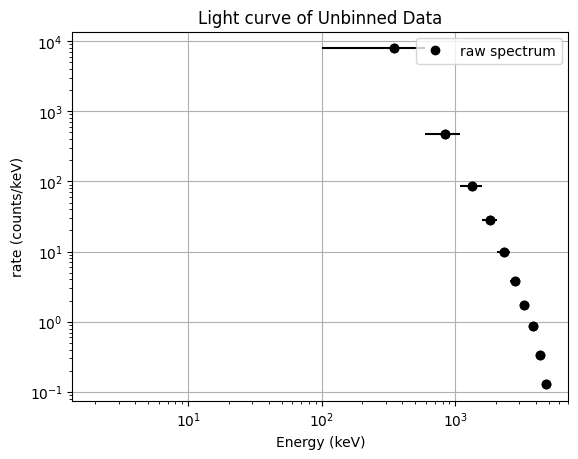

In [10]:
## binning reso

import h5py
import matplotlib.pyplot as plt
import numpy as np

# code is from StackOverflow https://stackoverflow.com/questions/46733052/read-hdf5-file-into-numpy-array
hf = h5py.File("unbinned_data.hdf5", "r")
dict_to_arr = hf.get('Energies')             # found key from cosipy read the docs under the function read_tra
energy_values = np.array(dict_to_arr)


#plt.hist returns a np.array of ([values], [edges])
Energy_count, Energy_bins, patches= plt.hist(energy_values, bins=10, histtype='step')

# axis is count vs energy
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Energy Distribution of Unbinned Data")
plt.show()

# try y-axis / x-axis to get the range of bins for light curve
# or try y-axis / x1-x2 to get the range of bins for light curve


bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2


import matplotlib.pyplot as plt

hf = h5py.File("unbinned_data.hdf5", "r")

# spectra graph is rate (count/keV^-1) vs energy (kev)
# x axis are the energy means???? idk man

# y axis is the rate (y/x from the histogram)
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2
rate = Energy_count / bins_widths_center  # rate is counts per bin width

#formating it all together
plt.loglog(bins_widths_center, rate, marker='o', color = 'black', linestyle='None', label = 'raw spectrum')

# why????? is it / 2
y_errors = (Energy_bins[1:] - Energy_bins[0:-1]) / 2  # calculate the bin widths for error bars

print(y_errors)

plt.errorbar(bins_widths_center, rate, xerr=y_errors, fmt='o', color='black')


plt.xlabel("Energy (keV)")
plt.ylabel("rate (counts/keV)")
plt.title("Light curve of Unbinned Data")
plt.legend()
plt.grid(True)
plt.show()